imports, drive connection and folder for eda's results


In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

output_dir = '/content/drive/MyDrive/Ketastasia/data/eda_results'
os.makedirs(output_dir, exist_ok=True)

print("done!")

Mounted at /content/drive
done!


dataset load and isolate splits

In [ ]:
data_path = '/content/drive/MyDrive/Ketastasia/data/pipeline1A_13kp.csv'
df = pd.read_csv(data_path)

train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()

print(f"full data: {df.shape}")
print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")
print("\nEDA - only for train.")

full data: (124072, 31)
Train: 88526
Val:   17523
Test:  18023

EDA - only for train.


/tmp/ipykernel_3297/4097397170.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


missing values

In [ ]:
print("Missing Values in Train Split")
print(f"Total missing values: {train_df.isnull().sum().sum()}")

Missing Values in Train Split
Total missing values: 0


data types

In [ ]:
print("Data Types Sample")
print(train_df[['video_id', 'source', 'frame', 'label', 'x0', 'y0']].dtypes)

Data Types Sample
video_id     object
source       object
frame         int64
label        object
x0          float64
y0          float64
dtype: object


class distribution

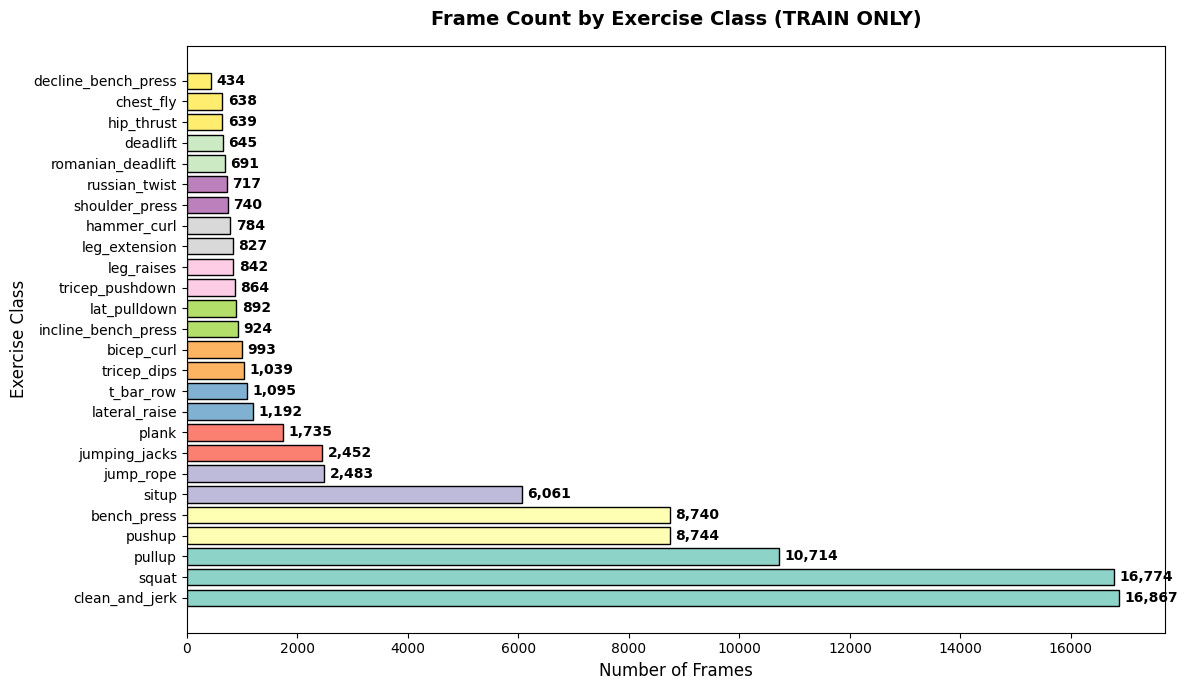

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

label_counts = train_df['label'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(label_counts)))

ax.barh(label_counts.index, label_counts.values, color=colors, edgecolor='black')
ax.set_title('Frame Count by Exercise Class (TRAIN ONLY)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Frames', fontsize=12)
ax.set_ylabel('Exercise Class', fontsize=12)

for i, v in enumerate(label_counts.values):
    ax.text(v + 100, i, f"{v:,}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

video and frame breakdown by source and split

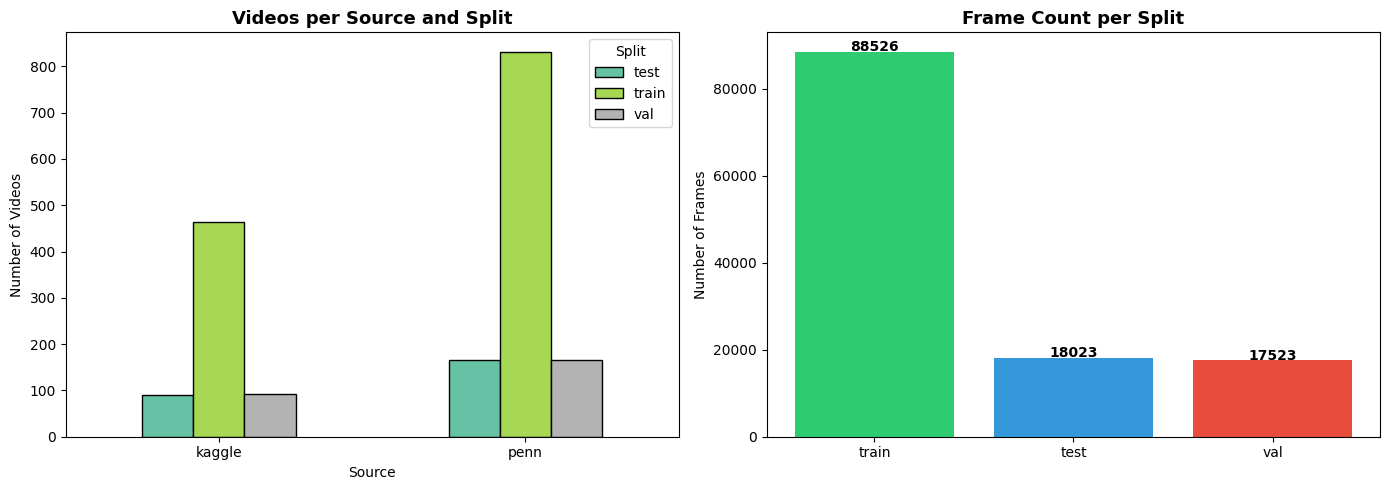

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# უნიკალური ვიდეოები Source და Split მიხედვით
source_split = df.groupby(['source', 'split'])['video_id'].nunique().unstack(fill_value=0)
source_split.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('Videos per Source and Split', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Source')
axes[0].set_ylabel('Number of Videos')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Split')

# კადრების ჯამი თითოეულ სპლიტში
split_counts = df['split'].value_counts()
axes[1].bar(split_counts.index, split_counts.values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Frame Count per Split', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Frames')
for i, v in enumerate(split_counts.values):
    axes[1].text(i, v + 200, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

 Normalization

In [ ]:
x_cols = [f'x{i}' for i in range(13)]
y_cols = [f'y{i}' for i in range(13)]

def normalize_pose_batch(target_df, x_cols, y_cols):
    """
    Per-frame normalization: hip-center centring & shoulder-hip distance scale (person-relative, camera-invariant).
    joint order: 0:head,1:l_shoulder,2:r_shoulder,3:l_elbow,4:r_elbow,5:l_wrist,6:r_wrist,7:l_hip,8:r_hip,9:l_knee,10:r_knee,11:l_ankle,12:r_ankle
    """
    xs = target_df[x_cols].values.astype(float)
    ys = target_df[y_cols].values.astype(float)

    center_x = (xs[:, 7] + xs[:, 8]) / 2
    center_y = (ys[:, 7] + ys[:, 8]) / 2
    scale = np.sqrt((xs[:, 1] - xs[:, 7])**2 + (ys[:, 1] - ys[:, 7])**2) + 1e-8

    xs_norm = (xs - center_x[:, None]) / scale[:, None]
    ys_norm = (ys - center_y[:, None]) / scale[:, None]

    target_df[x_cols] = xs_norm
    target_df[y_cols] = ys_norm
    return target_df

train_df = normalize_pose_batch(train_df, x_cols, y_cols)
val_df   = normalize_pose_batch(val_df, x_cols, y_cols)
test_df  = normalize_pose_batch(test_df, x_cols, y_cols)

print("per-frame normalization done!")

per-frame normalization done!


joint angles

In [ ]:
def calculate_angle(ax, ay, bx, by, cx, cy):
    ba = np.array([ax - bx, ay - by])
    bc = np.array([cx - bx, cy - by])
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

def extract_angles(target_df):
    target_df['angle_left_knee'] = target_df.apply(lambda r: calculate_angle(r['x7'], r['y7'], r['x9'], r['y9'], r['x11'], r['y11']), axis=1)
    target_df['angle_left_elbow'] = target_df.apply(lambda r: calculate_angle(r['x1'], r['y1'], r['x3'], r['y3'], r['x5'], r['y5']), axis=1)
    target_df['angle_left_hip'] = target_df.apply(lambda r: calculate_angle(r['x1'], r['y1'], r['x7'], r['y7'], r['x9'], r['y9']), axis=1)
    return target_df

train_df = extract_angles(train_df)
val_df   = extract_angles(val_df)
test_df  = extract_angles(test_df)

angle_cols = ['angle_left_knee', 'angle_left_elbow', 'angle_left_hip']
for angle_col in angle_cols:
    for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
        n_bad = d[angle_col].isna().sum()
        if n_bad > 0:
            print(f"{name} — {angle_col}: {n_bad} NaN, ვავსებთ label-median-ით")
            d[angle_col] = d[angle_col].fillna(d.groupby('label')[angle_col].transform('median'))

print("joint angles done!")

joint angles done!


/tmp/ipykernel_4197/1145677993.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_label, labels=unique_labels, patch_artist=True,
/tmp/ipykernel_4197/1145677993.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_label, labels=unique_labels, patch_artist=True,
/tmp/ipykernel_4197/1145677993.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_label, labels=unique_labels, patch_artist=True,


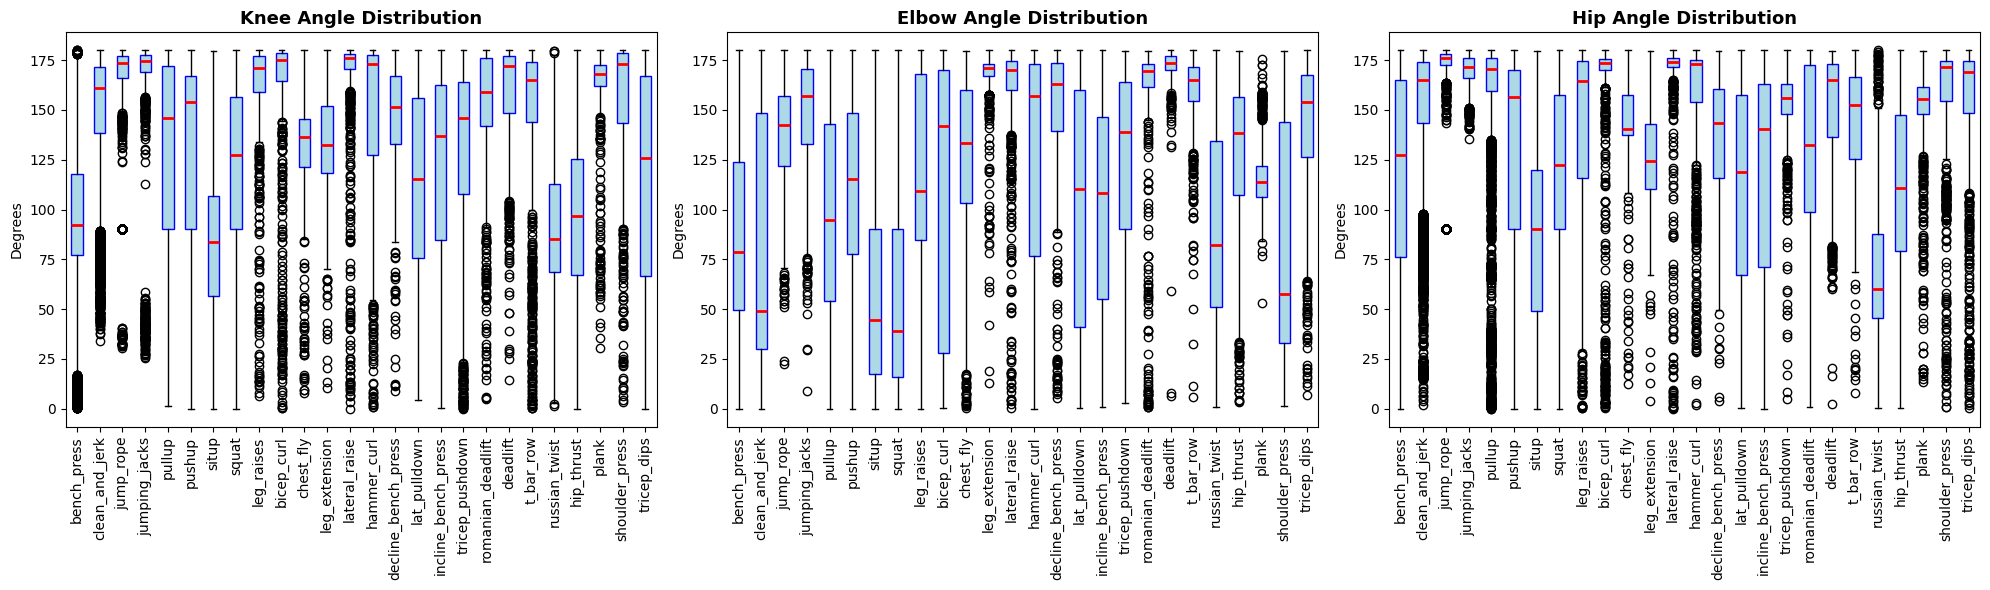

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
angles = ['angle_left_knee', 'angle_left_elbow', 'angle_left_hip']
titles = ['Knee Angle Distribution', 'Elbow Angle Distribution', 'Hip Angle Distribution']

unique_labels = train_df['label'].unique()

for ax, angle, title in zip(axes, angles, titles):
    data_by_label = [train_df[train_df['label']==l][angle].dropna().values for l in unique_labels]
    ax.boxplot(data_by_label, labels=unique_labels, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='blue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Degrees')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(f'{output_dir}/angle_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Frame Rate Matching & Cleansing

In [ ]:
def match_frame_rate(target_df):
    penn_m = target_df['source'] == 'penn'
    kaggle_m = target_df['source'] == 'kaggle'

    df_penn_sub = target_df[penn_m & (target_df['frame'] % 5 == 0)].copy()
    df_kaggle = target_df[kaggle_m].copy()

    df_matched = pd.concat([df_penn_sub, df_kaggle], ignore_index=True)
    return df_matched.sort_values(['video_id', 'frame']).reset_index(drop=True)

train_matched = match_frame_rate(train_df)
val_matched   = match_frame_rate(val_df)
test_matched  = match_frame_rate(test_df)

print("კადრების რაოდენობა მატჩინგის შემდეგ:")
print(f"  Train: {len(train_matched)}")
print(f"  Val:   {len(val_matched)}")
print(f"  Test:  {len(test_matched)}")

კადრების რაოდენობა მატჩინგის შემდეგ:
  Train: 33657
  Val:   6724
  Test:  6615


In [ ]:
feature_cols = x_cols + y_cols + angle_cols

def build_sequences_clean_text(matched_df, feature_cols, seq_len=15, step=7):
    X_list, y_list = [], []

    for video_id, group in matched_df.groupby('video_id'):
        group = group.sort_values('frame')
        feats = group[feature_cols].values
        label = group['label'].iloc[0]

        if len(feats) < seq_len:
            continue

        for start in range(0, len(feats) - seq_len + 1, step):
            X_list.append(feats[start:start + seq_len])
            y_list.append(label)

    return np.array(X_list), np.array(y_list)

X_tr_raw, y_train_text = build_sequences_clean_text(train_matched, feature_cols, seq_len=15, step=7)
X_val_raw, y_val_text   = build_sequences_clean_text(val_matched, feature_cols, seq_len=15, step=7)
X_test_raw, y_test_text  = build_sequences_clean_text(test_matched, feature_cols, seq_len=15, step=7)

print("აწყობილი მასივების ფორმები (Shapes):")
print(f"  X_train: {X_tr_raw.shape} | y_train (text): {y_train_text.shape}")
print(f"  X_val:   {X_val_raw.shape} | y_val (text):   {y_val_text.shape}")
print(f"  X_test:  {X_test_raw.shape} | y_test (text):  {y_test_text.shape}")

აწყობილი მასივების ფორმები (Shapes):
  X_train: (2940, 15, 29) | y_train (text): (2940,)
  X_val:   (580, 15, 29) | y_val (text):   (580,)
  X_test:  (574, 15, 29) | y_test (text):  (574,)


In [ ]:
original_classes = set(df['label'].unique())

final_classes = set(y_train_text)


dropped_classes = original_classes - final_classes

print(f"საწყისი კლასების რაოდენობა: {len(original_classes)}")
print(f"საბოლოო კლასების რაოდენობა: {len(final_classes)}")
print(f"ამოვარდნილი კლასი(ები): {dropped_classes}")

საწყისი კლასების რაოდენობა: 26
საბოლოო კლასების რაოდენობა: 25
ამოვარდნილი კლასი(ები): {'jumping_jacks'}


In [ ]:
n_timesteps = X_tr_raw.shape[1]
n_features = X_tr_raw.shape[2]

scaler = StandardScaler()

# ვასწავლით სკელერს და გარდავქმნით მხოლოდ Train დატაზე
X_train = scaler.fit_transform(X_tr_raw.reshape(-1, n_features)).reshape(X_tr_raw.shape)
X_val   = scaler.transform(X_val_raw.reshape(-1, n_features)).reshape(X_val_raw.shape)
X_test  = scaler.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape)

# ვპოულობთ მხოლოდ იმ რეალურ კლასებს, რომლებიც სექვენციებში დარჩნენ (ზუსტად 25)
unique_final_classes = sorted(list(np.unique(y_train_text)))

# შენახვა Google Drive-ზე (y მასივები ინახება ტექსტური სახით!)
save_path = '/content/drive/MyDrive/Ketastasia/data/dataset_seq15_ready.npz'
np.savez(save_path,
         X_train=X_train, y_train=y_train_text,
         X_val=X_val,     y_val=y_val_text,
         X_test=X_test,   y_test=y_test_text)

# მეტამონაცემების შენახვა
eda_stats = {
    "classes": unique_final_classes,
    "normalization": "per_frame_hip_centered_shoulder_scaled",
    "sequence_length": n_timesteps,
    "final_counts": {
        "train_sequences": X_train.shape[0],
        "val_sequences": X_val.shape[0],
        "test_sequences": X_test.shape[0]
    }
}
with open(f'{output_dir}/eda_stats.json', 'w') as f:
    json.dump(eda_stats, f, indent=4)

print("=== 🎉 უნივერსალური დატა-პაიპლაინი წარმატებით დასრულდა! ===")
print(f"ფაილი მზადაა ნებისმიერი მოდელისთვის: {save_path}")
print(f"Train: X={X_train.shape}, y_text={y_train_text.shape}")

=== 🎉 უნივერსალური დატა-პაიპლაინი წარმატებით დასრულდა! ===
ფაილი მზადაა ნებისმიერი მოდელისთვის: /content/drive/MyDrive/Ketastasia/data/dataset_seq15_ready.npz
Train: X=(2940, 15, 29), y_text=(2940,)
